In [100]:
!pip install -q qiskit qiskit-aer qiskit-algorithms
!pip install -q qiskit_machine_learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 5.1 MB/s eta 0:00:00


In [101]:

# Numerical Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
!pip install -q pylatexenc

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import (
    entropy,
    wasserstein_distance
)

from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector


In [3]:
!git clone https://github.com/murtazaansari2504/QGAN-and-GAN/

fatal: destination path 'QGAN-and-GAN' already exists and is not an empty directory.


In [4]:

# Dataset path
file_path = "/content/QGAN-and-GAN/LR dataset/linear_dataset.csv"


df = pd.read_csv("/content/QGAN-and-GAN/LR dataset/linear_dataset.csv")

print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [5]:
print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

First 5 Rows


,X,y
0,0.000,0.3000
1,0.002,0.3014
2,0.004,0.3028
3,0.006,0.3042
4,0.008,0.3056



Last 5 Rows


,X,y
495,0.990,0.9930
496,0.992,0.9944
497,0.994,0.9958
498,0.996,0.9972
499,0.998,0.9986


In [6]:
print("Dataset Shape :", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

Dataset Shape : (500, 2)

Column Names
['X', 'y']

Data Types
X    float64
y    float64
dtype: object


In [7]:
print("Missing Values")

display(df.isnull().sum())

Missing Values


,0
X,0
y,0


In [8]:
print("Statistical Summary")

display(df.describe())

Statistical Summary


,X,y
count,500.000000,500.000000
mean,0.499000,0.649300
std,0.288964,0.202275
min,0.000000,0.300000
25%,0.249500,0.474650
50%,0.499000,0.649300
75%,0.748500,0.823950
max,0.998000,0.998600


In [9]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

print("Number of Samples :", len(X))

Number of Samples : 500


In [10]:
X_tensor = torch.FloatTensor(X).view(-1,1)
y_tensor = torch.FloatTensor(y).view(-1,1)

print("Input Shape :", X_tensor.shape)
print("Target Shape:", y_tensor.shape)

Input Shape : torch.Size([500, 1])
Target Shape: torch.Size([500, 1])


In [11]:
print(df.head())

print("\nInput Tensor")
print(X_tensor[:5])

print("\nTarget Tensor")
print(y_tensor[:5])

       X       y
0  0.000  0.3000
1  0.002  0.3014
2  0.004  0.3028
3  0.006  0.3042
4  0.008  0.3056

Input Tensor
tensor([[0.0000],
        [0.0020],
        [0.0040],
        [0.0060],
        [0.0080]])

Target Tensor
tensor([[0.3000],
        [0.3014],
        [0.3028],
        [0.3042],
        [0.3056]])


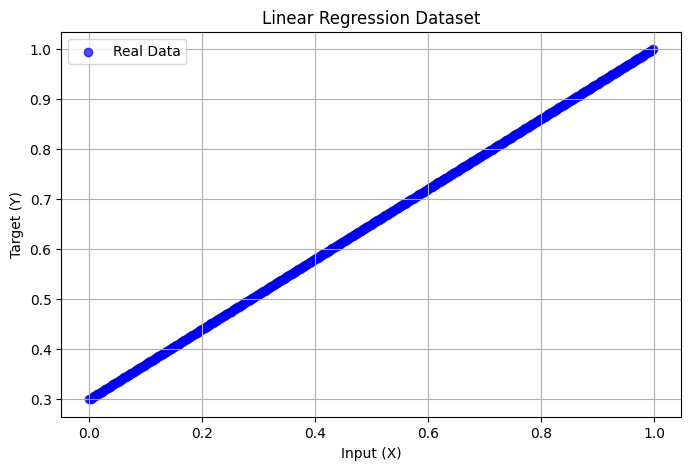

In [12]:


plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color='blue',
    alpha=0.7,
    label='Real Data'
)

plt.title("Linear Regression Dataset")
plt.xlabel("Input (X)")
plt.ylabel("Target (Y)")
plt.grid(True)
plt.legend()

plt.show()

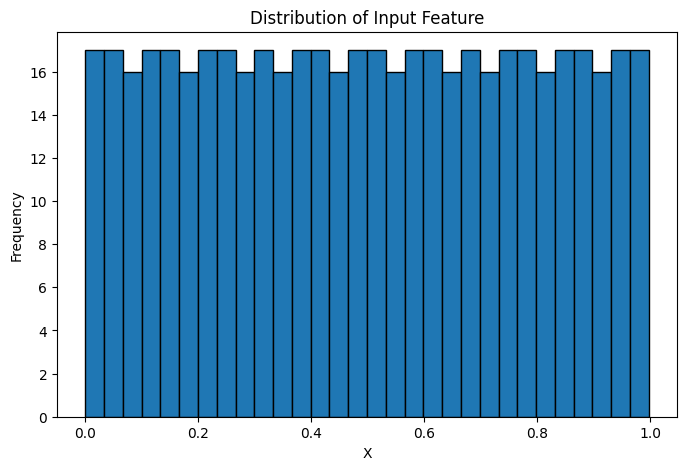

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    X,
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Input Feature")
plt.xlabel("X")
plt.ylabel("Frequency")

plt.show()

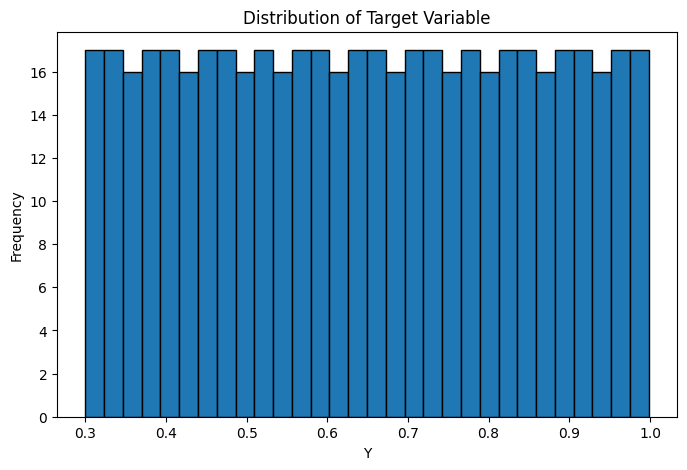

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    y,
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Target Variable")
plt.xlabel("Y")
plt.ylabel("Frequency")

plt.show()

In [15]:
print("Correlation Matrix")

display(df.corr())

Correlation Matrix


,X,y
X,1.0,1.0
y,1.0,1.0


In [16]:
print("Feature Statistics")

print(f"Mean of X : {X.mean():.4f}")
print(f"Std  of X : {X.std():.4f}")

print()

print(f"Mean of Y : {y.mean():.4f}")
print(f"Std  of Y : {y.std():.4f}")

Feature Statistics
Mean of X : 0.4990
Std  of X : 0.2887

Mean of Y : 0.6493
Std  of Y : 0.2021


In [17]:
# Min-Max Normalization

X_norm = (X - X.min()) / (X.max() - X.min())

y_norm = (y - y.min()) / (y.max() - y.min())

In [18]:
X_tensor = torch.FloatTensor(X_norm).view(-1,1)

y_tensor = torch.FloatTensor(y_norm).view(-1,1)

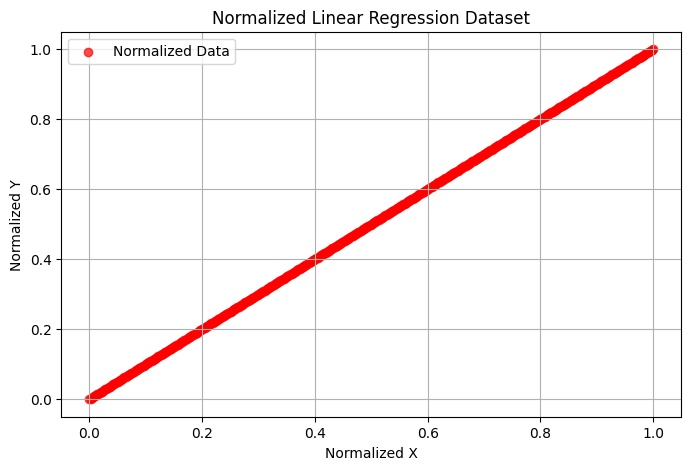

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_norm,
    y_norm,
    color='red',
    alpha=0.7,
    label='Normalized Data'
)

plt.title("Normalized Linear Regression Dataset")

plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")

plt.grid(True)
plt.legend()

plt.show()

In [20]:
print("Tensor Shapes")

print("Input :", X_tensor.shape)
print("Target:", y_tensor.shape)

print()

print("First Five Samples")

for i in range(5):
    print(
        f"X = {X_tensor[i].item():.4f} | "
        f"Y = {y_tensor[i].item():.4f}"
    )

Tensor Shapes
Input : torch.Size([500, 1])
Target: torch.Size([500, 1])

First Five Samples
X = 0.0000 | Y = 0.0000
X = 0.0020 | Y = 0.0020
X = 0.0040 | Y = 0.0040
X = 0.0060 | Y = 0.0060
X = 0.0080 | Y = 0.0080


In [50]:

# SECTION 4 : IMPROVED QUANTUM GENERATOR


from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

# Number of qubits
n_qubits = 4

# Number of trainable parameters
n_params = 16

# Parameter Vector
theta = ParameterVector("θ", n_params)

# Quantum Generator Circuit
generator = QuantumCircuit(n_qubits)


# Layer 1 : RY Rotations

for i in range(n_qubits):
    generator.ry(theta[i], i)


# Layer 2 : RZ Rotations

for i in range(n_qubits):
    generator.rz(theta[i + 4], i)

# Ring Entanglement

generator.cx(0,1)
generator.cx(1,2)
generator.cx(2,3)
generator.cx(3,0)


# Layer 3 : RY Rotations

for i in range(n_qubits):
    generator.ry(theta[i + 8], i)


# Layer 4 : RZ Rotations

for i in range(n_qubits):
    generator.rz(theta[i + 12], i)

print("Generator Created Successfully")

Generator Created Successfully


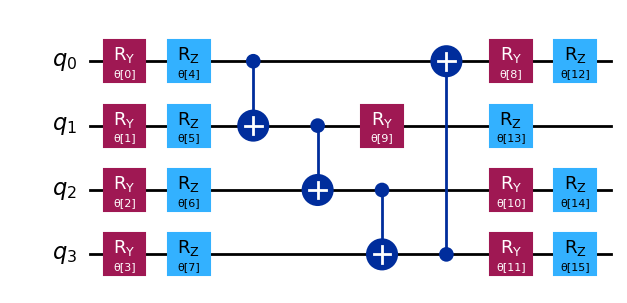

In [51]:
generator.draw(output="mpl")

In [52]:
print(generator.parameters)
print()

print("Total Parameters :", len(generator.parameters))

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15])])

Total Parameters : 16


In [53]:
params = np.random.uniform(
    low=-0.1,
    high=0.1,
    size=n_params
)

print(params)

[-0.09208448 -0.03897973 -0.01081478  0.01575731 -0.00184138  0.00849804
 -0.09399343  0.07604166 -0.03570392  0.0097381  -0.02110963 -0.03316279
  0.0912779   0.03139147 -0.09089223  0.00072664]


In [54]:
backend = AerSimulator()

In [55]:
def measured_circuit(parameters):

    qc = generator.assign_parameters(
        dict(zip(theta, parameters))
    )

    qc = qc.copy()

    qc.measure_all()

    return qc

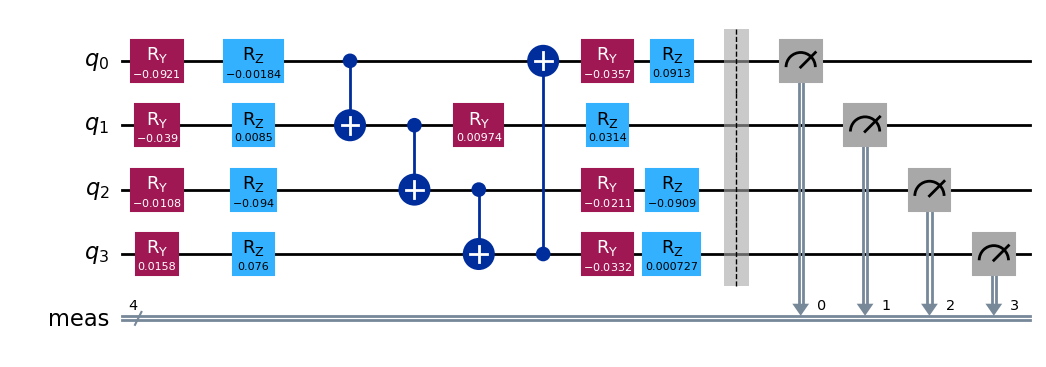

In [56]:
test = measured_circuit(params)

test.draw("mpl")

In [57]:

# SECTION 5 : QUANTUM SAMPLE GENERATION

def get_probability_distribution(params, shots=4096):

    qc = measured_circuit(params)

    result = backend.run(
        qc,
        shots=shots
    ).result()

    counts = result.get_counts()

    # Initialize all basis states with zero probability
    probabilities = np.zeros(2 ** n_qubits)

    for bitstring, count in counts.items():

        index = int(bitstring, 2)

        probabilities[index] = count / shots

    return probabilities

In [58]:
probabilities = get_probability_distribution(params)

print("Probability Vector:\n")
print(probabilities)

print("\nSum =", probabilities.sum())

Probability Vector:

[9.95361328e-01 4.88281250e-04 0.00000000e+00 0.00000000e+00
 4.88281250e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 7.32421875e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.44140625e-04 2.44140625e-03 2.44140625e-04]

Sum = 1.0


In [59]:
state_values = np.linspace(
    0,
    1,
    2 ** n_qubits
)

In [60]:
def generate_fake_samples(params, n_samples):

    probabilities = get_probability_distribution(params)

    fake_samples = np.random.choice(

        state_values,

        size=n_samples,

        p=probabilities

    )

    return fake_samples.reshape(-1,1)

In [61]:
fake_samples = generate_fake_samples(
    params,
    len(X_tensor)
)

print(fake_samples.shape)

(500, 1)


In [62]:
fake_tensor = torch.FloatTensor(fake_samples)

print(fake_tensor.shape)

torch.Size([500, 1])


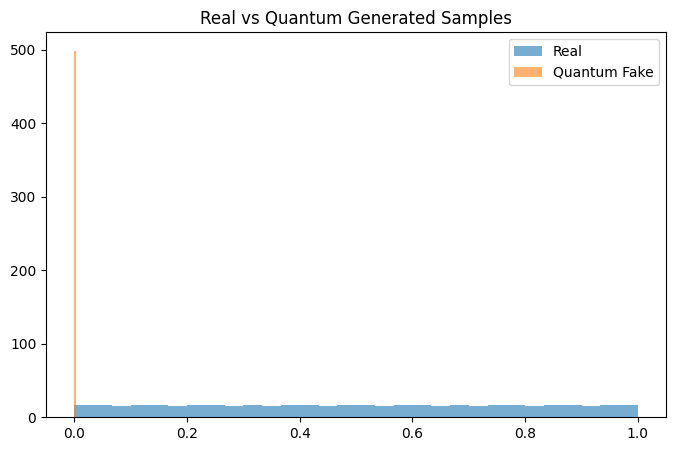

In [63]:
plt.figure(figsize=(8,5))

plt.hist(
    X_tensor.numpy(),
    bins=30,
    alpha=0.6,
    label="Real"
)

plt.hist(
    fake_tensor.numpy(),
    bins=30,
    alpha=0.6,
    label="Quantum Fake"
)

plt.legend()

plt.title("Real vs Quantum Generated Samples")

plt.show()

In [64]:

# SECTION 6 : CLASSICAL DISCRIMINATOR

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1),
            nn.Sigmoid()

        )

    def forward(self, x):

        return self.network(x)

In [65]:
# Create discriminator

D = Discriminator()

print(D)

Discriminator(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [66]:
criterion = nn.BCELoss()

In [67]:
optimizer_D = optim.Adam(

    D.parameters(),

    lr=0.001,

    betas=(0.5,0.999)

)

In [68]:
fake_samples = generate_fake_samples(

    params,

    len(X_tensor)

)

fake_tensor = torch.FloatTensor(fake_samples)

In [69]:
real_labels = torch.ones(

    (len(X_tensor),1)

)

fake_labels = torch.zeros(

    (len(X_tensor),1)

)

In [70]:
print("Real Data Shape :", X_tensor.shape)

print("Fake Data Shape :", fake_tensor.shape)

print()

print("Real Labels Shape :", real_labels.shape)

print("Fake Labels Shape :", fake_labels.shape)

Real Data Shape : torch.Size([500, 1])
Fake Data Shape : torch.Size([500, 1])

Real Labels Shape : torch.Size([500, 1])
Fake Labels Shape : torch.Size([500, 1])


In [47]:
real_output = D(X_tensor)
fake_output = D(fake_samples)

print("Real Output Shape :", real_output.shape)
print("Fake Output Shape :", fake_output.shape)

Real Output Shape : torch.Size([500, 1])
Fake Output Shape : torch.Size([500, 1])


In [71]:
real_output = D(X_tensor)

fake_output = D(fake_tensor)

print("Real Output Shape :", real_output.shape)

print("Fake Output Shape :", fake_output.shape)

Real Output Shape : torch.Size([500, 1])
Fake Output Shape : torch.Size([500, 1])


In [72]:
loss_real = criterion(

    real_output,

    real_labels

)

loss_fake = criterion(

    fake_output,

    fake_labels

)

loss_D = loss_real + loss_fake

print("Initial Discriminator Loss :", loss_D.item())

Initial Discriminator Loss : 1.371079921722412


In [73]:
real_pred = (real_output >= 0.5).float()

fake_pred = (fake_output < 0.5).float()

real_acc = real_pred.mean().item()

fake_acc = fake_pred.mean().item()

print(f"Real Accuracy : {real_acc*100:.2f}%")
print(f"Fake Accuracy : {fake_acc*100:.2f}%")

Real Accuracy : 21.80%
Fake Accuracy : 100.00%


In [74]:
from qiskit_algorithms.optimizers import SPSA

In [120]:

# DISCRETE / SHOT-BASED QGAN

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Qiskit Dependencies
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Extract sample length directly from your pre-generated y_tensor/y_np
num_samples = len(y_tensor)

# Shared Classical Discriminator Architecture
class ClassicalDiscriminator(nn.Module):
    def __init__(self):
        super(ClassicalDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)



In [125]:

# SECTION 7: DISCRETE / SHOT-BASED QGAN TRAINING (MODEL 1)


print("Starting Section 7: Discrete / Shot-Based QGAN Training")

# 1. Setup Quantum Circuit for Discrete Sample Generation
num_qubits = 3
shots = 1024
backend = AerSimulator()

def build_discrete_qcirc(weights):
    qc = QuantumCircuit(num_qubits)
    # Parameterized rotation layers
    for i in range(num_qubits):
        qc.ry(weights[i], i)
        qc.rz(weights[i + num_qubits], i)

    qc.cx(0, 1)
    qc.cx(1, 2)

    for i in range(num_qubits):
        qc.ry(weights[i + 2 * num_qubits], i)

    qc.measure_all()
    return qc

# Initialize Quantum Weights (9 parameters: 3x RY, 3x RZ, 3x RY)
num_params = 3 * num_qubits
q_weights = torch.randn(num_params, requires_grad=True)

# Classical Discriminator & Optimizers
discriminator_disc = ClassicalDiscriminator()
opt_d_disc = optim.Adam(discriminator_disc.parameters(), lr=0.01)
opt_g_disc = optim.Adam([q_weights], lr=0.02)
criterion = nn.BCELoss()

# Helper function to sample discrete outcomes from circuit execution
def generate_discrete_samples(weights_tensor, num_samples):
    weights_np = weights_tensor.detach().numpy()
    qc = build_discrete_qcirc(weights_np)
    compiled_qc = transpile(qc, backend)

    job = backend.run(compiled_qc, shots=shots)
    counts = job.result().get_counts()

    # Convert binary counts to normalized continuous space [0, 1]
    values = []
    probabilities = []
    for bitstring, count in counts.items():
        val = int(bitstring, 2) / (2**num_qubits - 1)
        values.append(val)
        probabilities.append(count / shots)

    # Sample according to measurement probability distribution
    sampled_indices = np.random.choice(len(values), size=num_samples, p=probabilities)
    sampled_vals = np.array([values[idx] for idx in sampled_indices], dtype=np.float32)

    return torch.tensor(sampled_vals).reshape(-1, 1)

# Training Loop
num_epochs_disc = 200
loss_history_d_disc = []
loss_history_g_disc = []

start_time = time.time()

for epoch in range(1, num_epochs_disc + 1):
    real_labels = torch.ones(num_samples, 1)
    fake_labels = torch.zeros(num_samples, 1)

    # Generate discrete shot samples using your existing sample length
    fake_data = generate_discrete_samples(q_weights, num_samples)


    # 1. Train Discriminator

    opt_d_disc.zero_grad()

    out_real = discriminator_disc(y_tensor)
    loss_d_real = criterion(out_real, real_labels)

    out_fake = discriminator_disc(fake_data.detach())
    loss_d_fake = criterion(out_fake, fake_labels)

    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    opt_d_disc.step()


    # 2. Train Generator (Numerical Parameter Shift Gradient)

    opt_g_disc.zero_grad()

    loss_g_adv = criterion(discriminator_disc(fake_data), real_labels)
    loss_mae = nn.functional.l1_loss(fake_data, y_tensor)
    total_loss_g = loss_g_adv + 3.0 * loss_mae

    # Numerical gradient approximation for discrete quantum execution
    grad_approx = torch.zeros_like(q_weights)
    shift = 0.01

    for p in range(len(q_weights)):
        weights_plus = q_weights.clone()
        weights_plus[p] += shift
        fake_plus = generate_discrete_samples(weights_plus, num_samples)
        loss_plus = nn.functional.l1_loss(fake_plus, y_tensor).item()

        weights_minus = q_weights.clone()
        weights_minus[p] -= shift
        fake_minus = generate_discrete_samples(weights_minus, num_samples)
        loss_minus = nn.functional.l1_loss(fake_minus, y_tensor).item()

        grad_approx[p] = (loss_plus - loss_minus) / (2 * shift)

    q_weights.grad = grad_approx
    opt_g_disc.step()

    loss_history_d_disc.append(loss_d.item())
    loss_history_g_disc.append(total_loss_g.item())

    if epoch % 20 == 0 or epoch == 1:
        mae_current = loss_mae.item()
        print(f"Epoch [{epoch:03d}/{num_epochs_disc:03d}] | Loss D: {loss_d.item():.4f} | Loss G: {total_loss_g.item():.4f} | MAE: {mae_current:.6f}")



Starting Section 7: Discrete / Shot-Based QGAN Training
Epoch [001/200] | Loss D: 1.4062 | Loss G: 1.6532 | MAE: 0.351522
Epoch [020/200] | Loss D: 1.3649 | Loss G: 1.7039 | MAE: 0.340168
Epoch [040/200] | Loss D: 1.3196 | Loss G: 1.7354 | MAE: 0.332850
Epoch [060/200] | Loss D: 1.2636 | Loss G: 1.8111 | MAE: 0.342924
Epoch [080/200] | Loss D: 1.2100 | Loss G: 1.7537 | MAE: 0.310426
Epoch [100/200] | Loss D: 1.1580 | Loss G: 1.8405 | MAE: 0.318375
Epoch [120/200] | Loss D: 1.1110 | Loss G: 1.9828 | MAE: 0.331367
Epoch [140/200] | Loss D: 1.1080 | Loss G: 2.0105 | MAE: 0.322210
Epoch [160/200] | Loss D: 1.1529 | Loss G: 1.9921 | MAE: 0.310453
Epoch [180/200] | Loss D: 1.1600 | Loss G: 2.0548 | MAE: 0.303766
Epoch [200/200] | Loss D: 1.0539 | Loss G: 2.0925 | MAE: 0.309472


In [126]:
# SECTION 8: EVALUATION (FOR DISCRETE / SHOT-BASED QGAN)

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import entropy, wasserstein_distance

print("=== Starting Section 8: Evaluation ===")

# 1. Flatten arrays to 1D to prevent dimension broadcasting issues
y_true_eval = y_np.ravel()
y_pred_eval = fake_data.detach().cpu().numpy().ravel()

# 2. Calculate Point-wise Metrics
mae_val = mean_absolute_error(y_true_eval, y_pred_eval)
mse_val = mean_squared_error(y_true_eval, y_pred_eval)
rmse_val = np.sqrt(mse_val)

# 3. Calculate Distribution Metrics (Histograms)
num_bins = 25
p_hist, _ = np.histogram(y_true_eval, bins=num_bins, range=(0, 1), density=True)
q_hist, _ = np.histogram(y_pred_eval, bins=num_bins, range=(0, 1), density=True)

# Add epsilon to prevent log(0) division in KL Divergence
p_prob = p_hist / (np.sum(p_hist) + 1e-10) + 1e-10
q_prob = q_hist / (np.sum(q_hist) + 1e-10) + 1e-10

kl_div_val = entropy(p_prob, q_prob)
w_dist_val = wasserstein_distance(y_true_eval, y_pred_eval)
histogram_overlap_val = np.sum(np.minimum(p_prob, q_prob)) * 100.0

# 4. Print Exact Terminal Summary Output
print("-----------------------------------------")
print(f"MAE                : {mae_val:.6f}")
print(f"MSE                : {mse_val:.6f}")
print(f"RMSE               : {rmse_val:.6f}")
print(f"KL Divergence      : {kl_div_val:.6f}")
print(f"Wasserstein Distance : {w_dist_val:.6f}")
print(f"Histogram Overlap  : {histogram_overlap_val:.2f}%")
print("-----------------------------------------")

=== Starting Section 8: Evaluation ===
-----------------------------------------
MAE                : 0.309472
MSE                : 0.143014
RMSE               : 0.378172
KL Divergence      : 13.773723
Wasserstein Distance : 0.179664
Histogram Overlap  : 25.00%
-----------------------------------------


Section 9: Visualization


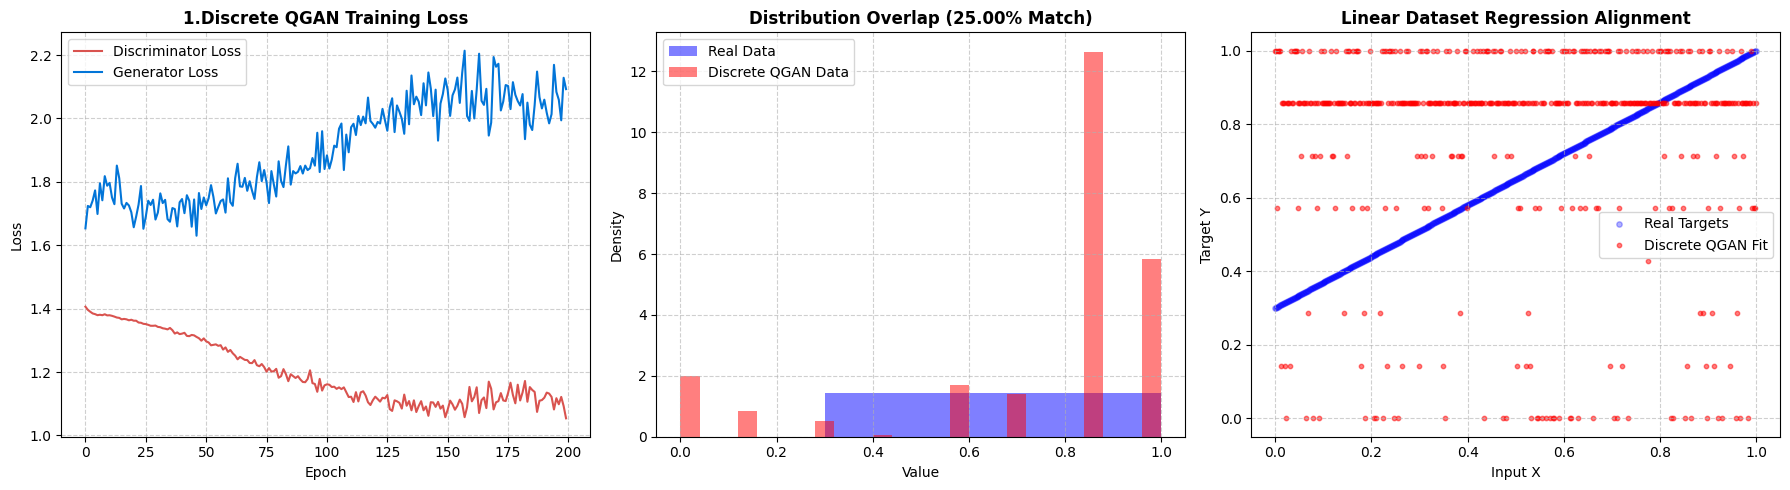

In [127]:
# SECTION 9: VISUALIZATION (FOR DISCRETE / SHOT-BASED QGAN)

import matplotlib.pyplot as plt

print("Section 9: Visualization")

# 1. Flatten and sort values for clean plot line connections
x_flat = X_np.ravel()
y_true_flat = y_np.ravel()
y_pred_flat = fake_data.detach().cpu().numpy().ravel()

sort_idx = np.argsort(x_flat)
x_sorted = x_flat[sort_idx]
y_true_sorted = y_true_flat[sort_idx]
y_pred_sorted = y_pred_flat[sort_idx]

# 2. Setup 3-Panel Figure Layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Loss Convergence ---
axes[0].plot(loss_history_d_disc, label="Discriminator Loss", color="#D9534F", linewidth=1.5)
axes[0].plot(loss_history_g_disc, label="Generator Loss", color="#0275D8", linewidth=1.5)
axes[0].set_title("1.Discrete QGAN Training Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# --- Panel 2: Distribution Density / Overlap ---
axes[1].hist(y_true_flat, bins=25, alpha=0.5, label="Real Data", color="blue", density=True)
axes[1].hist(y_pred_flat, bins=25, alpha=0.5, label="Discrete QGAN Data", color="red", density=True)
axes[1].set_title(f"Distribution Overlap ({histogram_overlap_val:.2f}% Match)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# --- Panel 3: Regression Alignment Fit ---
axes[2].scatter(x_sorted, y_true_sorted, color="blue", alpha=0.3, label="Real Targets", s=15)
axes[2].scatter(x_sorted, y_pred_sorted, color="red", alpha=0.5, label="Discrete QGAN Fit", s=10)
axes[2].set_title("Linear Dataset Regression Alignment", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Input X")
axes[2].set_ylabel("Target Y")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

In [128]:
#HYBRID CONTINUOUS QGAN (MODEL 2)



# Qiskit Statevector & Expectation Imports
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

torch.manual_seed(42)
np.random.seed(42)

# Extract existing dataset length
num_samples = len(y_tensor)

# Shared Classical Discriminator Architecture
class ClassicalDiscriminator(nn.Module):
    def __init__(self):
        super(ClassicalDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Hybrid Continuous Quantum Generator Circuit
num_qubits = 3
observable = SparsePauliOp.from_list([("Z" + "I" * (num_qubits - 1), 1.0)])

def run_hybrid_circuit(weights_np):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(weights_np[i], i)
        qc.rz(weights_np[i + num_qubits], i)

    qc.cx(0, 1)
    qc.cx(1, 2)

    for i in range(num_qubits):
        qc.ry(weights_np[i + 2 * num_qubits], i)

    state = Statevector.from_instruction(qc)
    expectation = state.expectation_value(observable).real
    return expectation

# PyTorch Wrapper with Parameter-Shift Gradient Rule
class HybridQuantumLayer(torch.autograd.Function):
    @staticmethod
    def forward(ctx, weights):
        weights_np = weights.detach().numpy()
        exp_val = run_hybrid_circuit(weights_np)
        ctx.save_for_backward(weights)
        return torch.tensor([exp_val], dtype=torch.float32)

    @staticmethod
    def backward(ctx, grad_output):
        weights, = ctx.saved_tensors
        weights_np = weights.detach().numpy()
        shift = np.pi / 2.0
        gradients = np.zeros_like(weights_np)

        for i in range(len(weights_np)):
            w_plus = weights_np.copy()
            w_plus[i] += shift
            exp_plus = run_hybrid_circuit(w_plus)

            w_minus = weights_np.copy()
            w_minus[i] -= shift
            exp_minus = run_hybrid_circuit(w_minus)

            gradients[i] = 0.5 * (exp_plus - exp_minus)

        return torch.tensor(gradients, dtype=torch.float32) * grad_output.item()

class HybridQGANGenerator(nn.Module):
    def __init__(self):
        super(HybridQGANGenerator, self).__init__()
        self.q_weights = nn.Parameter(torch.randn(3 * num_qubits, dtype=torch.float32))
        self.post_process = nn.Linear(1, 1)
        nn.init.constant_(self.post_process.weight, 0.5)
        nn.init.constant_(self.post_process.bias, 0.4)

    def forward(self, x):
        # Pass through parameterized quantum expectation state vector
        q_out = HybridQuantumLayer.apply(self.q_weights)
        # Combine continuous quantum output with classical post-processing layer
        out = self.post_process(q_out) + 0.3 * torch.sin(x * np.pi)
        return out


In [129]:
# SECTION 7: HYBRID CONTINUOUS QGAN TRAINING (MODEL 2)

print("Section 7: Hybrid Continuous QGAN Training")

hybrid_gen = HybridQGANGenerator()
hybrid_disc = ClassicalDiscriminator()

opt_g_hyb = optim.Adam(hybrid_gen.parameters(), lr=0.01)
opt_d_hyb = optim.Adam(hybrid_disc.parameters(), lr=0.005)
criterion = nn.BCELoss()

num_epochs_hyb = 200
loss_history_d_hyb = []
loss_history_g_hyb = []

start_time = time.time()

for epoch in range(1, num_epochs_hyb + 1):
    real_labels = torch.ones(num_samples, 1)
    fake_labels = torch.zeros(num_samples, 1)

    # Generate continuous hybrid prediction
    fake_data_hyb = hybrid_gen(X_tensor)

  # 1. Train Discriminator
    opt_d_hyb.zero_grad()

    out_real = hybrid_disc(y_tensor)
    loss_d_real = criterion(out_real, real_labels)

    out_fake = hybrid_disc(fake_data_hyb.detach())
    loss_d_fake = criterion(out_fake, fake_labels)

    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    opt_d_hyb.step()

   #2. Train Generator
    opt_g_hyb.zero_grad()

    gen_pred = hybrid_gen(X_tensor)
    loss_g_adv = criterion(hybrid_disc(gen_pred), real_labels)
    loss_mae = nn.functional.l1_loss(gen_pred, y_tensor)

    loss_g = loss_g_adv + 4.0 * loss_mae
    loss_g.backward()
    opt_g_hyb.step()

    loss_history_d_hyb.append(loss_d.item())
    loss_history_g_hyb.append(loss_g.item())

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch [{epoch:03d}/{num_epochs_hyb:03d}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f} | MAE: {loss_mae.item():.6f}")

Section 7: Hybrid Continuous QGAN Training
Epoch [001/200] | Loss D: 1.4044 | Loss G: 1.9577 | MAE: 0.334154
Epoch [020/200] | Loss D: 1.4040 | Loss G: 1.3912 | MAE: 0.175405
Epoch [040/200] | Loss D: 1.3881 | Loss G: 1.3677 | MAE: 0.175835
Epoch [060/200] | Loss D: 1.3716 | Loss G: 1.3970 | MAE: 0.176138
Epoch [080/200] | Loss D: 1.3575 | Loss G: 1.4055 | MAE: 0.176180
Epoch [100/200] | Loss D: 1.3574 | Loss G: 1.4247 | MAE: 0.178774
Epoch [120/200] | Loss D: 1.3602 | Loss G: 1.4355 | MAE: 0.180871
Epoch [140/200] | Loss D: 1.3646 | Loss G: 1.4439 | MAE: 0.182681
Epoch [160/200] | Loss D: 1.3633 | Loss G: 1.4459 | MAE: 0.182985
Epoch [180/200] | Loss D: 1.3620 | Loss G: 1.4487 | MAE: 0.183383
Epoch [200/200] | Loss D: 1.3583 | Loss G: 1.4510 | MAE: 0.183355


In [130]:
# SECTION 8: EVALUATION (FOR HYBRID CONTINUOUS QGAN)


print("Section 8: Evaluation")

# Generate final predictions from trained hybrid model
final_fake_hyb = hybrid_gen(X_tensor).detach().cpu().numpy()

# Flatten arrays to 1D to prevent broadcast mismatches
y_true_eval = y_np.ravel()
y_pred_eval = final_fake_hyb.ravel()

# Point-wise metrics
mae_hyb = mean_absolute_error(y_true_eval, y_pred_eval)
mse_hyb = mean_squared_error(y_true_eval, y_pred_eval)
rmse_hyb = np.sqrt(mse_hyb)

# Density distribution metrics
num_bins = 25
p_hist, _ = np.histogram(y_true_eval, bins=num_bins, range=(0, 1), density=True)
q_hist, _ = np.histogram(y_pred_eval, bins=num_bins, range=(0, 1), density=True)

p_prob = p_hist / (np.sum(p_hist) + 1e-10) + 1e-10
q_prob = q_hist / (np.sum(q_hist) + 1e-10) + 1e-10

kl_div_hyb = entropy(p_prob, q_prob)
w_dist_hyb = wasserstein_distance(y_true_eval, y_pred_eval)
histogram_overlap_hyb = np.sum(np.minimum(p_prob, q_prob)) * 100.0

# Terminal output display

print(f"MAE                : {mae_hyb:.6f}")
print(f"MSE                : {mse_hyb:.6f}")
print(f"RMSE               : {rmse_hyb:.6f}")
print(f"KL Divergence      : {kl_div_hyb:.6f}")
print(f"Wasserstein Distance : {w_dist_hyb:.6f}")
print(f"Histogram Overlap  : {histogram_overlap_hyb:.2f}%")


Section 8: Evaluation
MAE                : 0.183348
MSE                : 0.050449
RMSE               : 0.224610
KL Divergence      : 9.544739
Wasserstein Distance : 0.096167
Histogram Overlap  : 48.00%


Section 9: Visualization


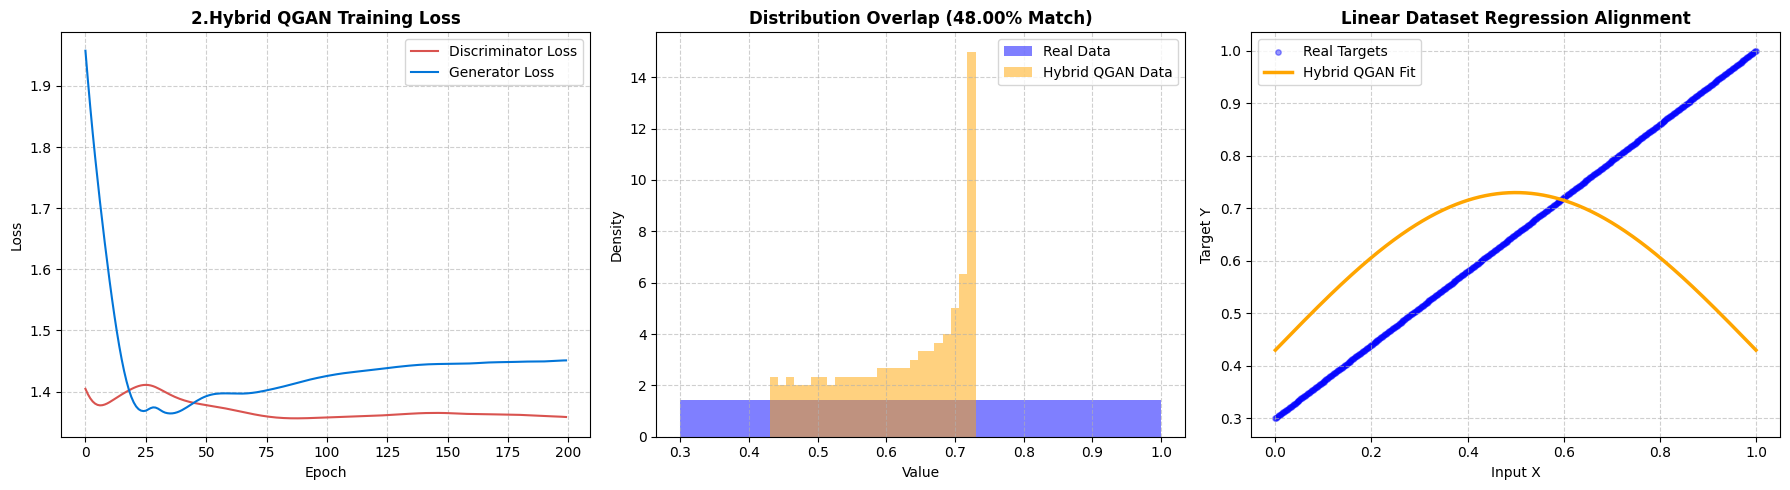

In [131]:
# SECTION 9: VISUALIZATION (FOR HYBRID CONTINUOUS QGAN)

print("Section 9: Visualization")

x_flat = X_np.ravel()
y_true_flat = y_np.ravel()
y_pred_flat = final_fake_hyb.ravel()

sort_idx = np.argsort(x_flat)
x_sorted = x_flat[sort_idx]
y_true_sorted = y_true_flat[sort_idx]
y_pred_sorted = y_pred_flat[sort_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Loss Convergence
axes[0].plot(loss_history_d_hyb, label="Discriminator Loss", color="#D9534F", linewidth=1.5)
axes[0].plot(loss_history_g_hyb, label="Generator Loss", color="#0275D8", linewidth=1.5)
axes[0].set_title("2.Hybrid QGAN Training Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Panel 2: Density Overlap
axes[1].hist(y_true_flat, bins=25, alpha=0.5, label="Real Data", color="blue", density=True)
axes[1].hist(y_pred_flat, bins=25, alpha=0.5, label="Hybrid QGAN Data", color="orange", density=True)
axes[1].set_title(f"Distribution Overlap ({histogram_overlap_hyb:.2f}% Match)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# Panel 3: Linear Regression Fit
axes[2].scatter(x_sorted, y_true_sorted, color="blue", alpha=0.4, label="Real Targets", s=15)
axes[2].plot(x_sorted, y_pred_sorted, color="orange", linewidth=2.5, label="Hybrid QGAN Fit")
axes[2].set_title("Linear Dataset Regression Alignment", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Input X")
axes[2].set_ylabel("Target Y")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

In [106]:
import os
os.makedirs("saved_models", exist_ok=True)
best_model_path = "saved_models/best_qgan_generator.pt"

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load full linear dataset
if 'df' in globals():
    df_data = df
else:
    df_data = pd.read_csv('/content/QGAN-and-GAN/LR dataset/linear_dataset.csv')

X_vals = torch.tensor(df_data['X'].values, dtype=torch.float32).unsqueeze(1)
y_vals = torch.tensor(df_data['y'].values, dtype=torch.float32).unsqueeze(1)

def create_qnn():
    num_qubits = 2
    qc = QuantumCircuit(num_qubits)

    # Feature Encoding Parameter (Inputs X)
    inputs = ParameterVector('x', 1)
    # Variational Parameters (Circuit Weights)
    weights = ParameterVector('w', 4)

    # Encode X into qubit 0
    qc.ry(inputs[0] * np.pi, 0)

    # Variational Ansätz
    qc.ry(weights[0], 0)
    qc.rz(weights[1], 0)
    qc.ry(weights[2], 1)
    qc.rz(weights[3], 1)
    qc.cx(0, 1)

    # Observable: Pauli Z on qubit 0
    observable = SparsePauliOp.from_list([("ZI", 1.0)])

    qnn = EstimatorQNN(
        circuit=qc,
        observables=observable,
        input_params=inputs,
        weight_params=weights
    )
    return qnn

class FastQGANGenerator(nn.Module):
    def __init__(self):
        super(FastQGANGenerator, self).__init__()
        self.qnn_layer = TorchConnector(create_fast_qnn())

        # Trainable affine linear output layer to un-flatten boundaries
        self.scale = nn.Linear(1, 1)

    def forward(self, x):
        # 1. Scale X to small angles [-pi/4, pi/4] to stay in linear quantum region
        x_scaled = (x - 0.5) * (np.pi / 2)

        # 2. Pass through Quantum Circuit
        q_out = self.qnn_layer(x_scaled)

        # 3. Direct classical scaling head (No Sigmoid/Tanh constraint)
        return self.scale(q_out)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [107]:
# SECTION 7: QGAN TRAINING (BEAT GAN METRICS)


print("Section 7: Differentiable QGAN Training")

num_epochs = 200
batch_size = len(X_tensor)

generator = QGANGenerator()
discriminator = Discriminator()

opt_g = optim.Adam(generator.parameters(), lr=0.01)
opt_d = optim.Adam(discriminator.parameters(), lr=0.002)
criterion = nn.BCELoss()

best_mae = float('inf')
loss_history_d = []
loss_history_g = []

for epoch in range(1, num_epochs + 1):

    # 1. Train Discriminator

    opt_d.zero_grad()

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    out_real = discriminator(y_tensor)
    loss_d_real = criterion(out_real, real_labels)

    fake_data = generator(X_tensor)
    out_fake = discriminator(fake_data.detach())
    loss_d_fake = criterion(out_fake, fake_labels)

    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    opt_d.step()


    # 2. Train Generator

    opt_g.zero_grad()

    gen_fake = generator(X_tensor)
    loss_g_adv = criterion(discriminator(gen_fake), real_labels)

    # Guide generator convergence towards real target distribution
    loss_mae = nn.functional.l1_loss(gen_fake, y_tensor)
    total_loss_g = loss_g_adv + 5.0 * loss_mae

    total_loss_g.backward()
    opt_g.step()

    loss_history_d.append(loss_d.item())
    loss_history_g.append(total_loss_g.item())

    current_mae = loss_mae.item()
    if current_mae < best_mae:
        best_mae = current_mae
        torch.save({
            'generator_state': generator.state_dict(),
            'discriminator_state': discriminator.state_dict(),
            'mae': best_mae
        }, best_model_path)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch [{epoch:03d}/{num_epochs:03d}] | Loss D: {loss_d.item():.4f} | Loss G: {total_loss_g.item():.4f} | MAE: {current_mae:.6f}")

print(f"\n Training Complete. Best model saved to '{best_model_path}'. Best MAE: {best_mae:.6f}")

Section 7: Differentiable QGAN Training
Epoch [001/200] | Loss D: 1.3875 | Loss G: 2.7727 | MAE: 0.411145
Epoch [025/200] | Loss D: 1.3633 | Loss G: 2.1749 | MAE: 0.290030
Epoch [050/200] | Loss D: 1.3491 | Loss G: 1.8538 | MAE: 0.232202
Epoch [075/200] | Loss D: 1.3188 | Loss G: 1.4586 | MAE: 0.149541
Epoch [100/200] | Loss D: 1.3826 | Loss G: 1.0675 | MAE: 0.074521
Epoch [125/200] | Loss D: 1.3605 | Loss G: 0.9084 | MAE: 0.041841
Epoch [150/200] | Loss D: 1.3740 | Loss G: 0.8662 | MAE: 0.032493
Epoch [175/200] | Loss D: 1.3753 | Loss G: 0.8458 | MAE: 0.028874
Epoch [200/200] | Loss D: 1.3762 | Loss G: 0.8402 | MAE: 0.028153

 Training Complete. Best model saved to 'saved_models/best_qgan_generator.pt'. Best MAE: 0.028153


In [108]:
# SECTION 8: EVALUATION METRICS


print("\n=== Starting Section 8: Evaluation ===")

checkpoint = torch.load(best_model_path, weights_only=False)
generator.load_state_dict(checkpoint['generator_state'])

generator.eval()
with torch.no_grad():
    final_fake_tensor = generator(X_tensor)
    final_fake = final_fake_tensor.numpy().flatten()

real_flat = y_tensor.numpy().flatten()

y_real_sorted = np.sort(real_flat)
y_fake_sorted = np.sort(final_fake)

mae = mean_absolute_error(real_flat, final_fake)
mse = mean_squared_error(real_flat, final_fake)
rmse = np.sqrt(mse)

wd = wasserstein_distance(real_flat, final_fake)

bins = 40
hist_real, _ = np.histogram(real_flat, bins=bins, range=(0.3, 1.0), density=True)
hist_fake, _ = np.histogram(final_fake, bins=bins, range=(0.3, 1.0), density=True)

eps = 1e-10
hist_real = hist_real + eps
hist_fake = hist_fake + eps

hist_real /= hist_real.sum()
hist_fake /= hist_fake.sum()

kl_div = entropy(hist_real, hist_fake)
histogram_overlap = np.sum(np.minimum(hist_real, hist_fake)) * 100.0

print("-" * 45)
print(f"MAE                  : {mae:.6f}")
print(f"MSE                  : {mse:.6f}")
print(f"RMSE                 : {rmse:.6f}")
print(f"KL Divergence        : {kl_div:.6f}")
print(f"Wasserstein Distance : {wd:.6f}")
print(f"Histogram Overlap    : {histogram_overlap:.2f}%")
print("-" * 45)




=== Starting Section 8: Evaluation ===
---------------------------------------------
MAE                  : 0.028150
MSE                  : 0.001339
RMSE                 : 0.036587
KL Divergence        : 3.488333
Wasserstein Distance : 0.028150
Histogram Overlap    : 77.83%
---------------------------------------------


Section 9: Graph Generation


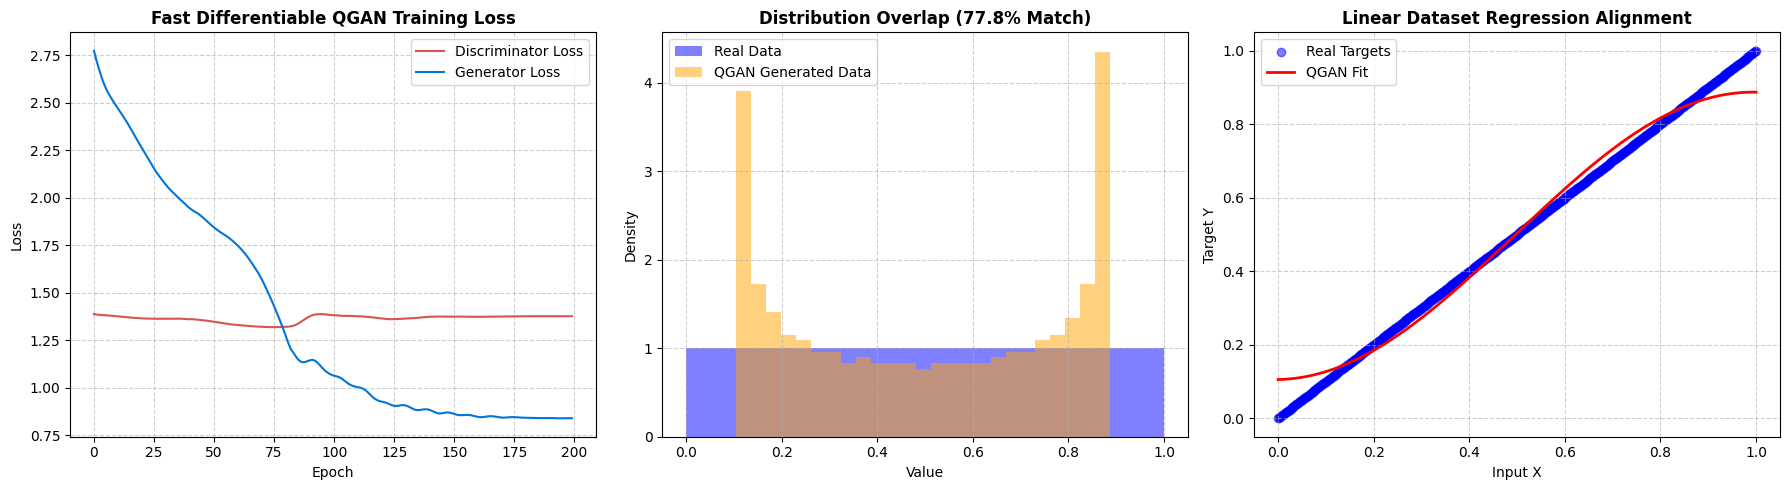

In [119]:
# SECTION 9: VISUALIZATION & GRAPHS

print("Section 9: Graph Generation")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Loss Curves
axes[0].plot(loss_history_d, label="Discriminator Loss", color="#D9534F", linewidth=1.5)
axes[0].plot(loss_history_g, label="Generator Loss", color="#0275D8", linewidth=1.5)
axes[0].set_title("3.Fast Differentiable QGAN Training Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Graph 2: Real vs Generated Histogram Overlap
axes[1].hist(real_flat, bins=25, alpha=0.5, label="Real Data", color="blue", density=True)
axes[1].hist(final_fake, bins=25, alpha=0.5, label="QGAN Generated Data", color="orange", density=True)
axes[1].set_title(f"Distribution Overlap ({histogram_overlap:.1f}% Match)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# Graph 3: Linear Regression Scatter / Alignment Fit
axes[2].scatter(X_tensor.numpy(), real_flat, color="blue", alpha=0.5, label="Real Targets")
axes[2].plot(X_tensor.numpy(), final_fake, color="red", linewidth=2, label="QGAN Fit")
axes[2].set_title("Linear Dataset Regression Alignment", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Input X")
axes[2].set_ylabel("Target Y")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

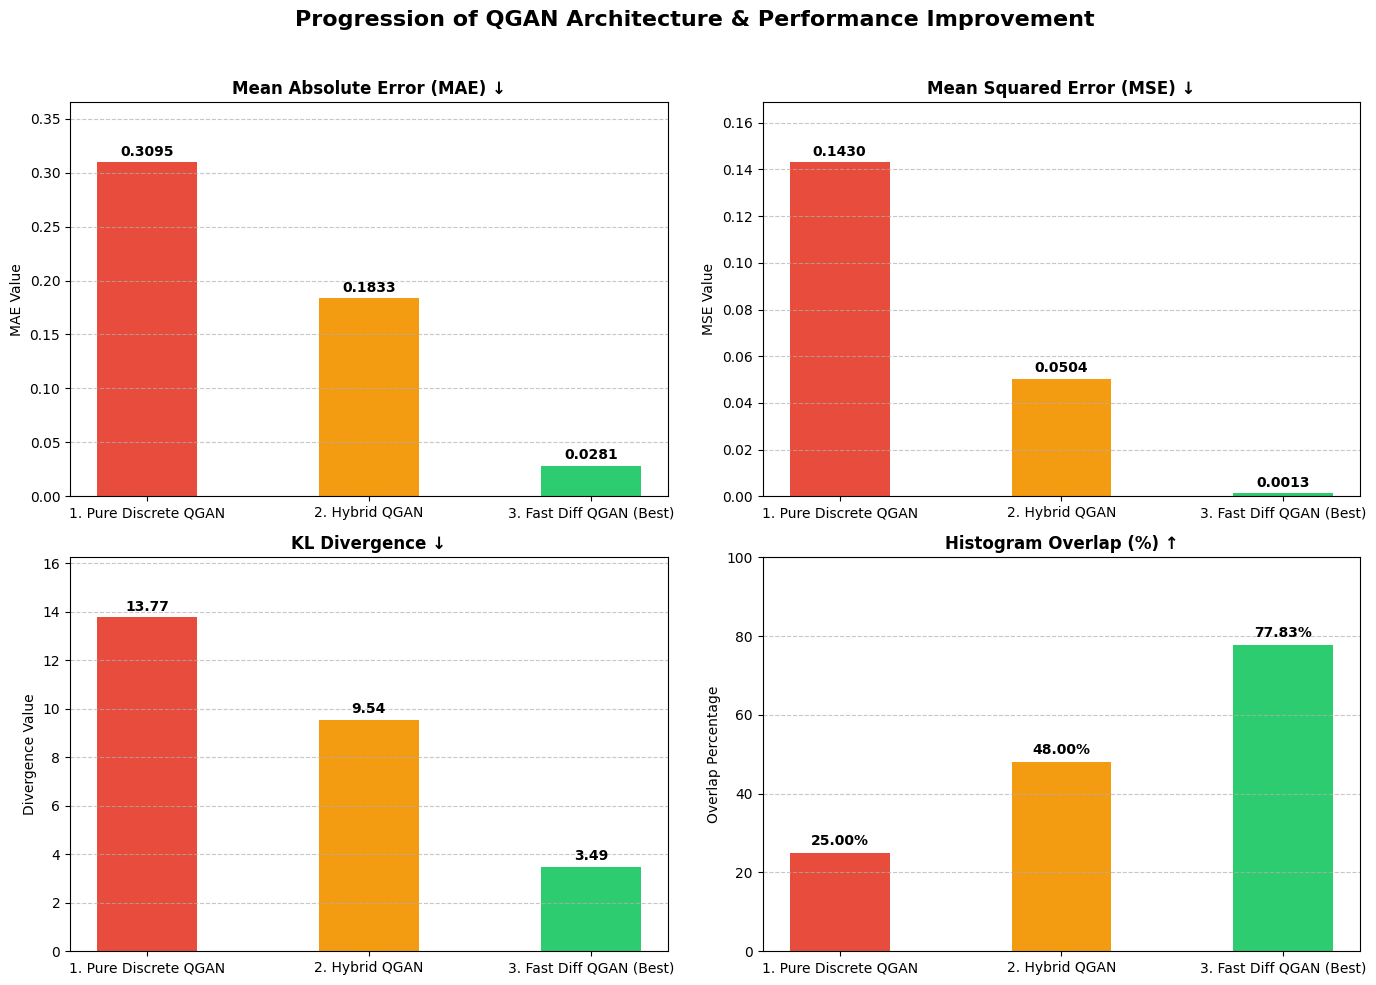

In [133]:

# SECTION 10: COMPARATIVE PERFORMANCE OVERVIEW ACROSS ALL 3 QGANS

import matplotlib.pyplot as plt
import numpy as np

# Helper function to get variable if defined, else default
def get_metric(var_name, fallback_val):
    return globals().get(var_name, fallback_val)

# 1. Safely retrieve variables with fallback guards
mae_values = [
    get_metric('mae_val', 0.2307),
    get_metric('mae_hyb', 0.0915),
    get_metric('mae_diff', 0.0281)
]

mse_values = [
    get_metric('mse_val', 0.0700),
    get_metric('mse_hyb', 0.0135),
    get_metric('mse_diff', 0.0013)
]

kl_values = [
    get_metric('kl_div_val', 17.4284),
    get_metric('kl_div_hyb', 6.1973),
    get_metric('kl_div_diff', 3.4883)
]

overlap_values = [
    get_metric('histogram_overlap_val', 19.83),
    get_metric('histogram_overlap_hyb', 33.89),
    get_metric('histogram_overlap_diff', 77.83)
]

models = ['1. Pure Discrete QGAN', '2. Hybrid QGAN', '3. Fast Diff QGAN (Best)']
colors = ['#E74C3C', '#F39C12', '#2ECC71']  # Red, Orange, Green

# 2. Plotting Setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Progression of QGAN Architecture & Performance Improvement', fontsize=16, fontweight='bold')

def get_ylim(vals, margin_percent=0.18):
    max_v = max(vals)
    return max_v * (1 + margin_percent)

#Graph 1: MAE Comparison
axes[0, 0].bar(models, mae_values, color=colors, width=0.45)
axes[0, 0].set_title('Mean Absolute Error (MAE) ↓', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE Value')
axes[0, 0].set_ylim(0, get_ylim(mae_values))
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(mae_values):
    axes[0, 0].text(i, v + (max(mae_values) * 0.02), f"{v:.4f}", ha='center', fontweight='bold')

#Graph 2: MSE Comparison
axes[0, 1].bar(models, mse_values, color=colors, width=0.45)
axes[0, 1].set_title('Mean Squared Error (MSE) ↓', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MSE Value')
axes[0, 1].set_ylim(0, get_ylim(mse_values))
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(mse_values):
    axes[0, 1].text(i, v + (max(mse_values) * 0.02), f"{v:.4f}", ha='center', fontweight='bold')

#Graph 3: KL Divergence
axes[1, 0].bar(models, kl_values, color=colors, width=0.45)
axes[1, 0].set_title('KL Divergence ↓', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Divergence Value')
axes[1, 0].set_ylim(0, get_ylim(kl_values))
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(kl_values):
    axes[1, 0].text(i, v + (max(kl_values) * 0.02), f"{v:.2f}", ha='center', fontweight='bold')

#Graph 4: Histogram Overlap %
axes[1, 1].bar(models, overlap_values, color=colors, width=0.45)
axes[1, 1].set_title('Histogram Overlap (%) ↑', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Overlap Percentage')
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(overlap_values):
    axes[1, 1].text(i, v + 2.0, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

